In [2]:
import pandas as pd

# ============================================================
# Read CSV
# ============================================================
df = pd.read_csv("575longdata.csv")

# Check column names
print("Columns:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

# ============================================================
# Extract time and current columns
# ============================================================
time_col = df.columns[0]
current_col = df.columns[1]

time = pd.to_numeric(df[time_col], errors="coerce")
current = pd.to_numeric(df[current_col], errors="coerce")

# Store data
data = pd.DataFrame({
    "Relative Time (s)": time,
    "Current (A)": current
})

# Remove invalid/missing values
data = data.dropna()

# ============================================================
# Ignore currents below 1.5e-6 A
# ============================================================
current_threshold = 1.5e-6

data = data[data["Current (A)"] >= current_threshold].copy()

# ============================================================
# Normalize time so the first remaining time value is 0
# ============================================================
data["Time (s)"] = (
    data["Relative Time (s)"]
    - data["Relative Time (s)"].iloc[0]
)

# ============================================================
# Calculate resistance
# V = 0.5 V
# R = V / I
# ============================================================
data["Resistance (Ω)"] = (
    0.5 / data["Current (A)"]
)

# ============================================================
# Reset index
# ============================================================
data = data.reset_index(drop=True)

# ============================================================
# Print summary
# ============================================================
print("\nCurrent threshold: 1.5e-6 A")
print(f"Number of data points retained: {len(data)}")

print("\nProcessed data:")
print(data.head())

print("\nFinal data point:")
print(data.tail(1))

Columns:
0 'Relative Time (1/10000 s)'
1 'Current (A)'

Current threshold: 1.5e-6 A
Number of data points retained: 500000

Processed data:
   Relative Time (s)  Current (A)  Time (s)  Resistance (Ω)
0             0.0000     0.000003    0.0000   197161.235978
1             0.0001     0.000003    0.0001   197179.993262
2             0.0002     0.000003    0.0002   197184.996986
3             0.0003     0.000003    0.0003   196966.325703
4             0.0004     0.000003    0.0004   196980.052335

Final data point:
        Relative Time (s)  Current (A)  Time (s)  Resistance (Ω)
499999            49.9999     0.000003   49.9999   175596.234786


Lamp 575 V:
Resistance at 5 s: 146007.25 Ω
Closest measured time: 5.000000 s


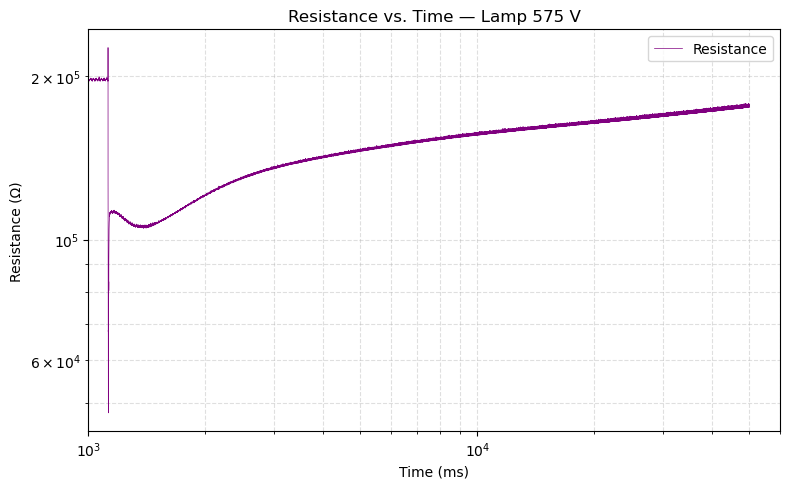

In [12]:
# ============================================================
# 575 V Resistance vs. Time — Log Scale
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

lamp = 575

# Extract data directly from the DataFrame
time = data["Time (s)"].to_numpy()
resistance = data["Resistance (Ω)"].to_numpy()

# ============================================================
# Remove invalid values
# ============================================================

mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,              # Convert seconds → milliseconds
    resistance,
    linewidth=0.5,
    label="Resistance",
    c="purple"
)

# ============================================================
# Logarithmic axes
# ============================================================

plt.yscale("log")
plt.xscale("log")

# ============================================================
# Labels and title
# ============================================================

plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.xlim(1000, 60000)

plt.title("Resistance vs. Time — Lamp 575 V")

# Grid
plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()

plt.tight_layout()
plt.show()

Lamp 575 V:
Resistance at 5 s: 146007.25 Ω
Closest measured time: 5.000000 s


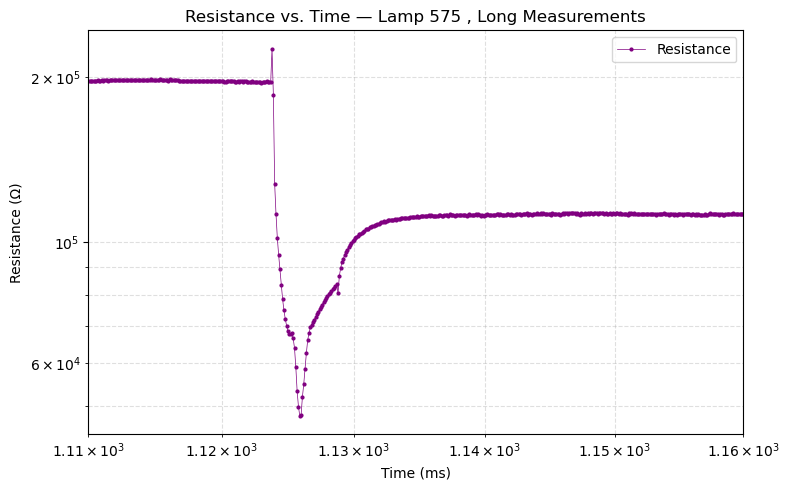

In [21]:
# ============================================================
# 575 V Resistance vs. Time — Log Scale
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

lamp = 575

# Extract data directly from the DataFrame
time = data["Time (s)"].to_numpy()
resistance = data["Resistance (Ω)"].to_numpy()

# ============================================================
# Remove invalid values
# ============================================================

mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.5,
    marker="o",
    markersize=2,
    label="Resistance",
    c="purple"
)

# ============================================================
# Logarithmic axes
# ============================================================

plt.yscale("log")
plt.xscale("log")

# ============================================================
# Labels and title
# ============================================================

plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.xlim(1110, 1160)

plt.title("Resistance vs. Time — Lamp 575 , Long Measurements")

# Grid
plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()

plt.tight_layout()
plt.show()

Lamp 575 V:
Resistance at 5 s: 146007.25 Ω
Closest measured time: 5.000000 s


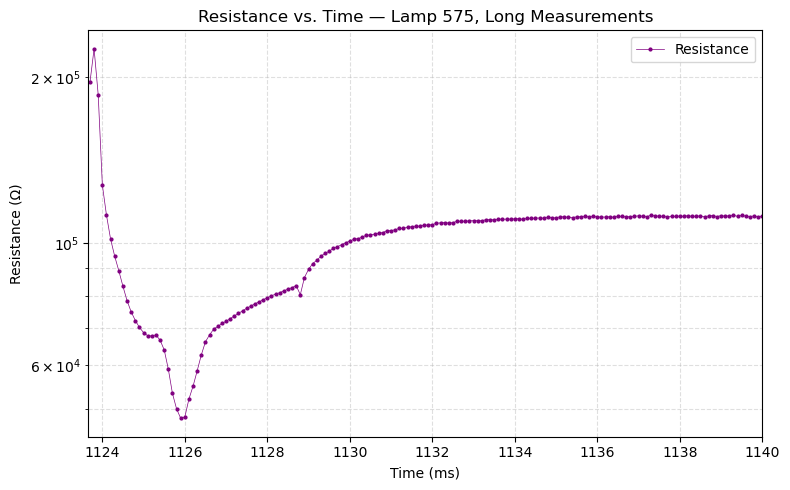

In [34]:
# ============================================================
# 575 V Resistance vs. Time — Log Scale
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

lamp = 575

# Extract data directly from the DataFrame
time = data["Time (s)"].to_numpy()
resistance = data["Resistance (Ω)"].to_numpy()

# ============================================================
# Remove invalid values
# ============================================================

mask = (
    np.isfinite(time)
    & np.isfinite(resistance)
    & (resistance > 0)
)

time = time[mask]
resistance = resistance[mask]

# ============================================================
# Find resistance at 5 seconds
# ============================================================

target_time = 5.0  # seconds

# Find measured point closest to 5 seconds
closest_index = np.argmin(np.abs(time - target_time))

closest_time = time[closest_index]
resistance_at_5s = resistance[closest_index]

print(f"Lamp {lamp} V:")
print(f"Resistance at 5 s: {resistance_at_5s:.2f} Ω")
print(f"Closest measured time: {closest_time:.6f} s")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    time * 1e3,
    resistance,
    linewidth=0.5,
    marker="o",
    markersize=2,
    label="Resistance",
    c="purple"
)


# ============================================================
# Labels and title
# ============================================================

plt.xlabel("Time (ms)")
plt.ylabel("Resistance (Ω)")
plt.xlim(1123.66, 1140)

plt.yscale("log")

plt.title("Resistance vs. Time — Lamp 575, Long Measurements")

# Grid
plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend()

plt.tight_layout()
plt.show()